In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

In [4]:
df = pd.read_csv("/content/insurance.csv")

print(df.head())
print(df.info())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)


Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [6]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

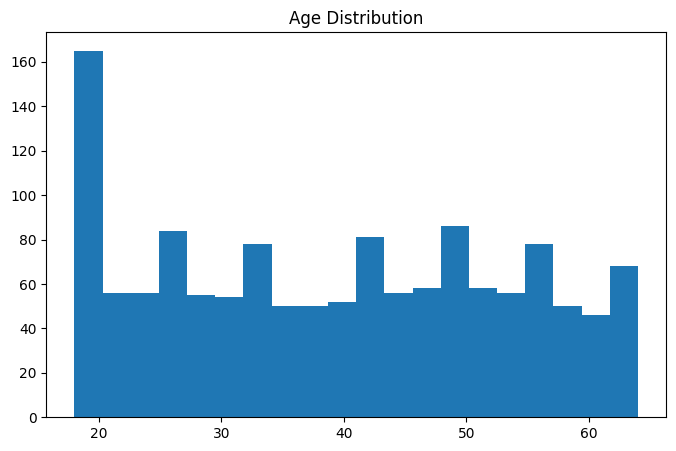

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.show()

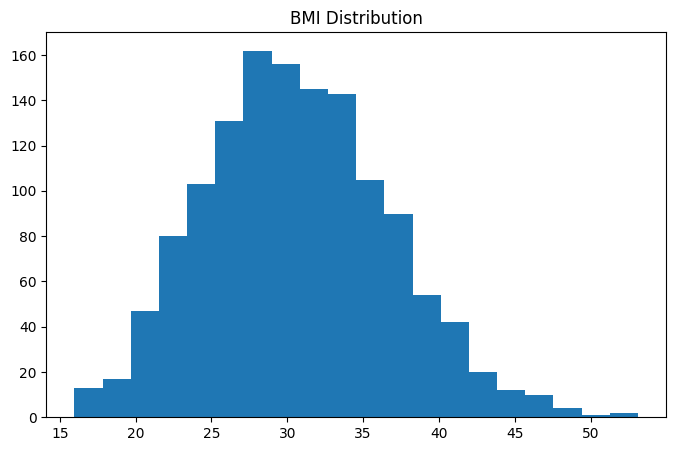

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['bmi'], bins=20)
plt.title("BMI Distribution")
plt.show()

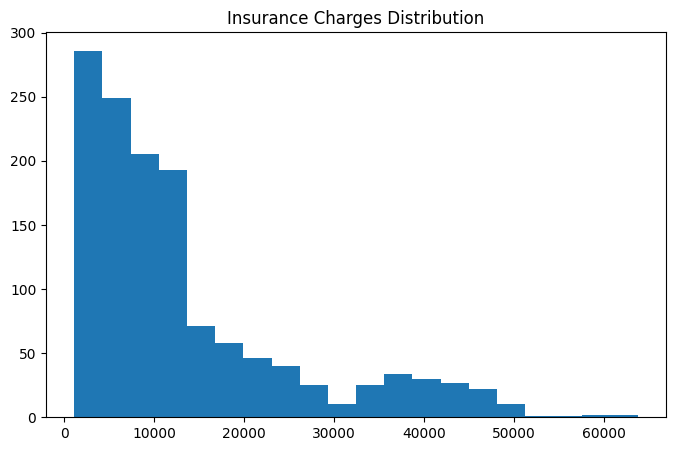

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df['charges'], bins=20)
plt.title("Insurance Charges Distribution")
plt.show()

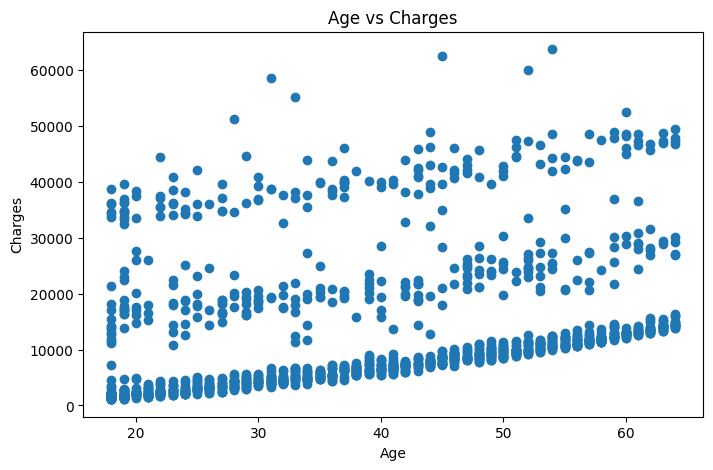

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df['age'], df['charges'])
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

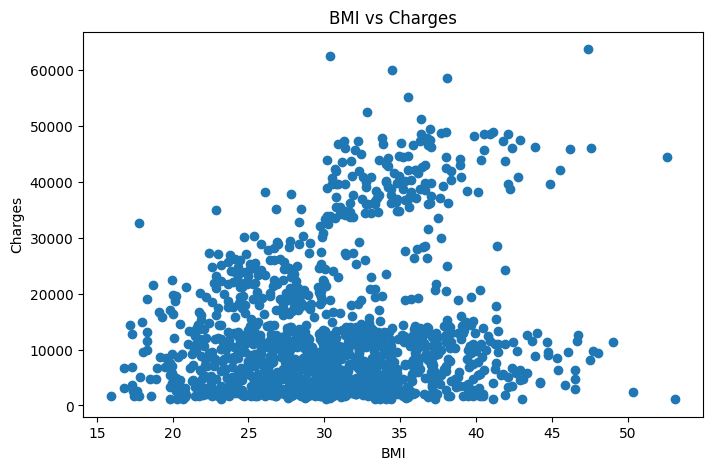

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(df['bmi'], df['charges'])
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

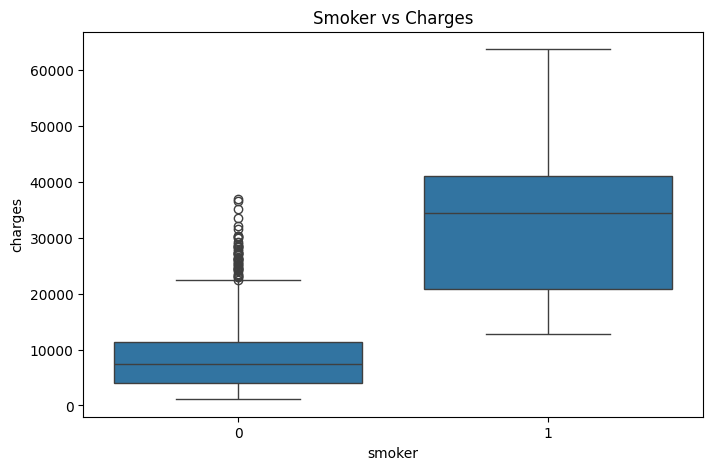

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Charges")
plt.show()

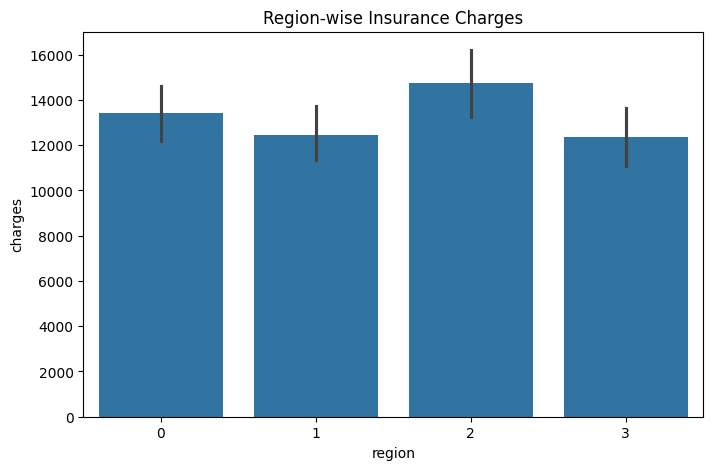

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x='region', y='charges', data=df)
plt.title("Region-wise Insurance Charges")
plt.show()

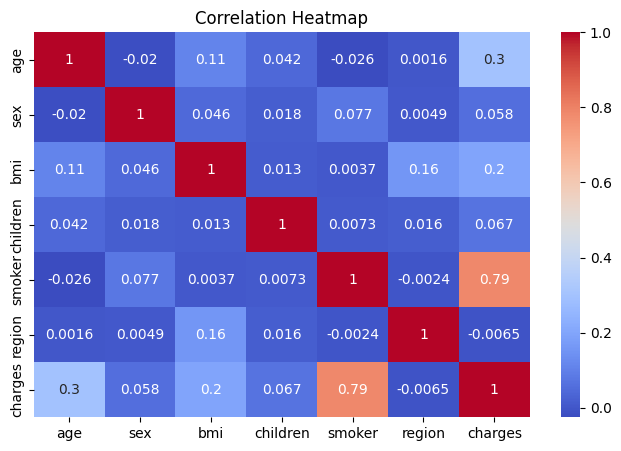

In [14]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [16]:
from sklearn.metrics import r2_score

X = df[['age']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Linear Regression R² Score:",
      r2_score(y_test, y_pred))

Linear Regression R² Score: 0.09513000782072023


In [17]:
X = df[['age', 'bmi', 'children', 'smoker']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred = mlr.predict(X_test)

print("Multiple Linear Regression R² Score:",
      r2_score(y_test, y_pred))

Multiple Linear Regression R² Score: 0.8045531086669288


In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix

df['insurance_category'] = np.where(
    df['charges'] > df['charges'].median(),
    1,
    0
)

X = df[['age', 'bmi', 'children', 'smoker']]
y = df['insurance_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9067164179104478
[[117  15]
 [ 10 126]]
